# Graph Neural Networks (GNNs)

This notebook will cover everything on GNN models using PyTorch and PyTorch Geometric (PyG).

In [3]:
!pip install torch torch_geometric networkx matplotlib scikit-learn

## Setting up our Environment

For modern GNNs, **PyTorch Geometric (PyG)** is the industry standard. It's built on top of PyTorch and provides highly optimized implementations of graph operations.

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric
import networkx as nx
import matplotlib.pyplot as plt

## Creating and Visualizing Graphs

Let's create a simple graph from scratch. In PyG, a graph is represented by a `Data` object, which takes:
- `x`: Node feature matrix
- `edge_index`: Graph connectivity (COO format)
- `y`: Target labels

In [5]:
from torch_geometric.data import Data

# 1. Define edges (connections)
# edge_index represents [source_nodes, target_nodes]
edge_index = torch.tensor([[0, 1, 1, 2],
                           [1, 0, 2, 1]], dtype=torch.long)

# 2. Define node features (e.g., 3 nodes, each with 2 features)
x = torch.tensor([[-1., 0.], [0., 1.], [1., 0.]], dtype=torch.float)

# 3. Create the Data object
data = Data(x=x, edge_index=edge_index)
print(data)

Data(x=[3, 2], edge_index=[2, 4])


Let's visualize this simple graph using NetworkX. PyG provides a convenient conversion function.

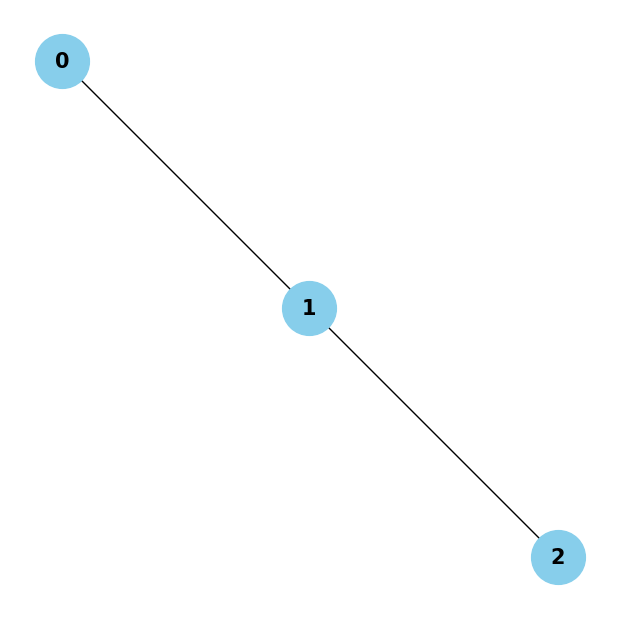

In [6]:
from torch_geometric.utils import to_networkx
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'


def visualize_graph(data):
    G = to_networkx(data, to_undirected=True)
    plt.figure(figsize=(6, 6))
    nx.draw(G, with_labels=True, node_color='skyblue', node_size=1500, font_weight='bold', font_size=15)
    plt.show()

visualize_graph(data)

## The Cora Dataset: Node Classification

To see GNNs in action, we'll use the famous **Cora dataset**. It's a citation network where nodes are documents, and edges are citations. The goal is to classify the category of each document based on its text features and its citations.

In [7]:
from torch_geometric.datasets import Planetoid

# Load the dataset
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

print(f'Dataset: {dataset.name}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Is undirected: {data.is_undirected()}')

Dataset: Cora
Number of features: 1433
Number of classes: 7
Number of nodes: 2708
Number of edges: 10556
Has isolated nodes: False
Is undirected: True


## Message Passing & Graph Convolutional Networks (GCNs)

The core of a GNN is the **Message Passing** paradigm. Nodes update their features by aggregating features from their neighbors. 

A Graph Convolutional Network (GCN) applies a simple weighted average of neighboring node features, followed by a linear transformation and a non-linearity.

In [12]:
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(GCN, self).__init__()
        # First GCN Layer: Input features -> Hidden features
        self.conv1 = GCNConv(dataset.num_features, hidden_channels)
        # Second GCN Layer: Hidden features -> Classes
        self.conv2 = GCNConv(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index):
        # 1. First message passing step
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        
        # 2. Second message passing step
        x = self.conv2(x, edge_index)
        return x

model = GCN(hidden_channels=16)
print(model)

GCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)


## Training the GNN

Training a GNN is very similar to training any PyTorch model. We'll use the cross-entropy loss function since this is a classification problem. Notice that we only calculate the loss on the `train_mask` elements.

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

def train():
    model.train()
    optimizer.zero_grad()  # Clear gradients
    out = model(data.x, data.edge_index)  # Perform a single forward pass
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes
    loss.backward()  # Derive gradients
    optimizer.step()  # Update parameters based on gradients
    return loss

def test():
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)  # Use the class with highest probability
    test_correct = pred[data.test_mask] == data.y[data.test_mask]  # Check against ground-truth labels
    test_acc = int(test_correct.sum()) / int(data.test_mask.sum())  # Derive ratio of correct predictions
    return test_acc

# Train for 500 epochs
for epoch in range(1, 501):
    loss = train()
    if epoch % 10 == 0:
        acc = test()
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Test Acc: {acc:.4f}')

Epoch: 010, Loss: 0.8314, Test Acc: 0.7640
Epoch: 020, Loss: 0.2297, Test Acc: 0.7920
Epoch: 030, Loss: 0.1172, Test Acc: 0.7860
Epoch: 040, Loss: 0.0684, Test Acc: 0.7840
Epoch: 050, Loss: 0.0440, Test Acc: 0.7940
Epoch: 060, Loss: 0.0294, Test Acc: 0.7990
Epoch: 070, Loss: 0.0359, Test Acc: 0.7930
Epoch: 080, Loss: 0.0243, Test Acc: 0.7940
Epoch: 090, Loss: 0.0350, Test Acc: 0.8040
Epoch: 100, Loss: 0.0355, Test Acc: 0.7970
Epoch: 110, Loss: 0.0297, Test Acc: 0.8010
Epoch: 120, Loss: 0.0286, Test Acc: 0.8060
Epoch: 130, Loss: 0.0355, Test Acc: 0.7990
Epoch: 140, Loss: 0.0280, Test Acc: 0.8070
Epoch: 150, Loss: 0.0355, Test Acc: 0.8070
Epoch: 160, Loss: 0.0242, Test Acc: 0.7950
Epoch: 170, Loss: 0.0351, Test Acc: 0.8010
Epoch: 180, Loss: 0.0242, Test Acc: 0.7900
Epoch: 190, Loss: 0.0324, Test Acc: 0.8040
Epoch: 200, Loss: 0.0254, Test Acc: 0.7910
Epoch: 210, Loss: 0.0200, Test Acc: 0.8050
Epoch: 220, Loss: 0.0247, Test Acc: 0.8050
Epoch: 230, Loss: 0.0300, Test Acc: 0.7990
Epoch: 240,

In [ ]:
from torch_geometric.nn import GATConv
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

class GAT(torch.nn.Module):
    def __init__(self, hidden_channels, heads=8):
        super().__init__()
        self.conv1 = GATConv(dataset.num_features, hidden_channels, heads=heads, dropout=0.6)
        self.conv2 = GATConv(hidden_channels * heads, dataset.num_classes, heads=1, concat=False, dropout=0.6)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv2(x, edge_index)
        return x


def evaluate_model(model_to_eval):
    model_to_eval.eval()
    with torch.no_grad():
        logits = model_to_eval(data.x, data.edge_index)
        pred = logits.argmax(dim=1)
    y_true = data.y[data.test_mask].cpu().numpy()
    y_pred = pred[data.test_mask].cpu().numpy()
    return {
        "logits": logits.detach().cpu(),
        "pred": pred.detach().cpu(),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "y_true": y_true,
        "y_pred": y_pred,
    }


def train_gat(model_to_train, optimizer_to_use, epochs=60, log_every=10):
    history = {"loss": [], "test_acc": []}
    for epoch in range(1, epochs + 1):
        model_to_train.train()
        optimizer_to_use.zero_grad()
        out = model_to_train(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer_to_use.step()

        history["loss"].append(loss.item())
        if epoch % log_every == 0:
            metrics = evaluate_model(model_to_train)
            history["test_acc"].append((epoch, metrics["accuracy"]))
            print(f"GAT | Epoch: {epoch:03d}, Loss: {loss:.4f}, Test Acc: {metrics['accuracy']:.4f}")
    return history


gat_model = GAT(hidden_channels=8, heads=8)
optimizer_gat = torch.optim.Adam(gat_model.parameters(), lr=0.005, weight_decay=5e-4)
gat_history = train_gat(gat_model, optimizer_gat, epochs=60, log_every=10)

model_results = {
    "GCN": evaluate_model(model),
    "GAT": evaluate_model(gat_model),
}

for name, results in model_results.items():
    print(
        f"{name}: accuracy={results['accuracy']:.4f}, "
        f"precision={results['precision']:.4f}, recall={results['recall']:.4f}, f1={results['f1']:.4f}"
    )

Calculating graph layout... (this might take 10-20 seconds)


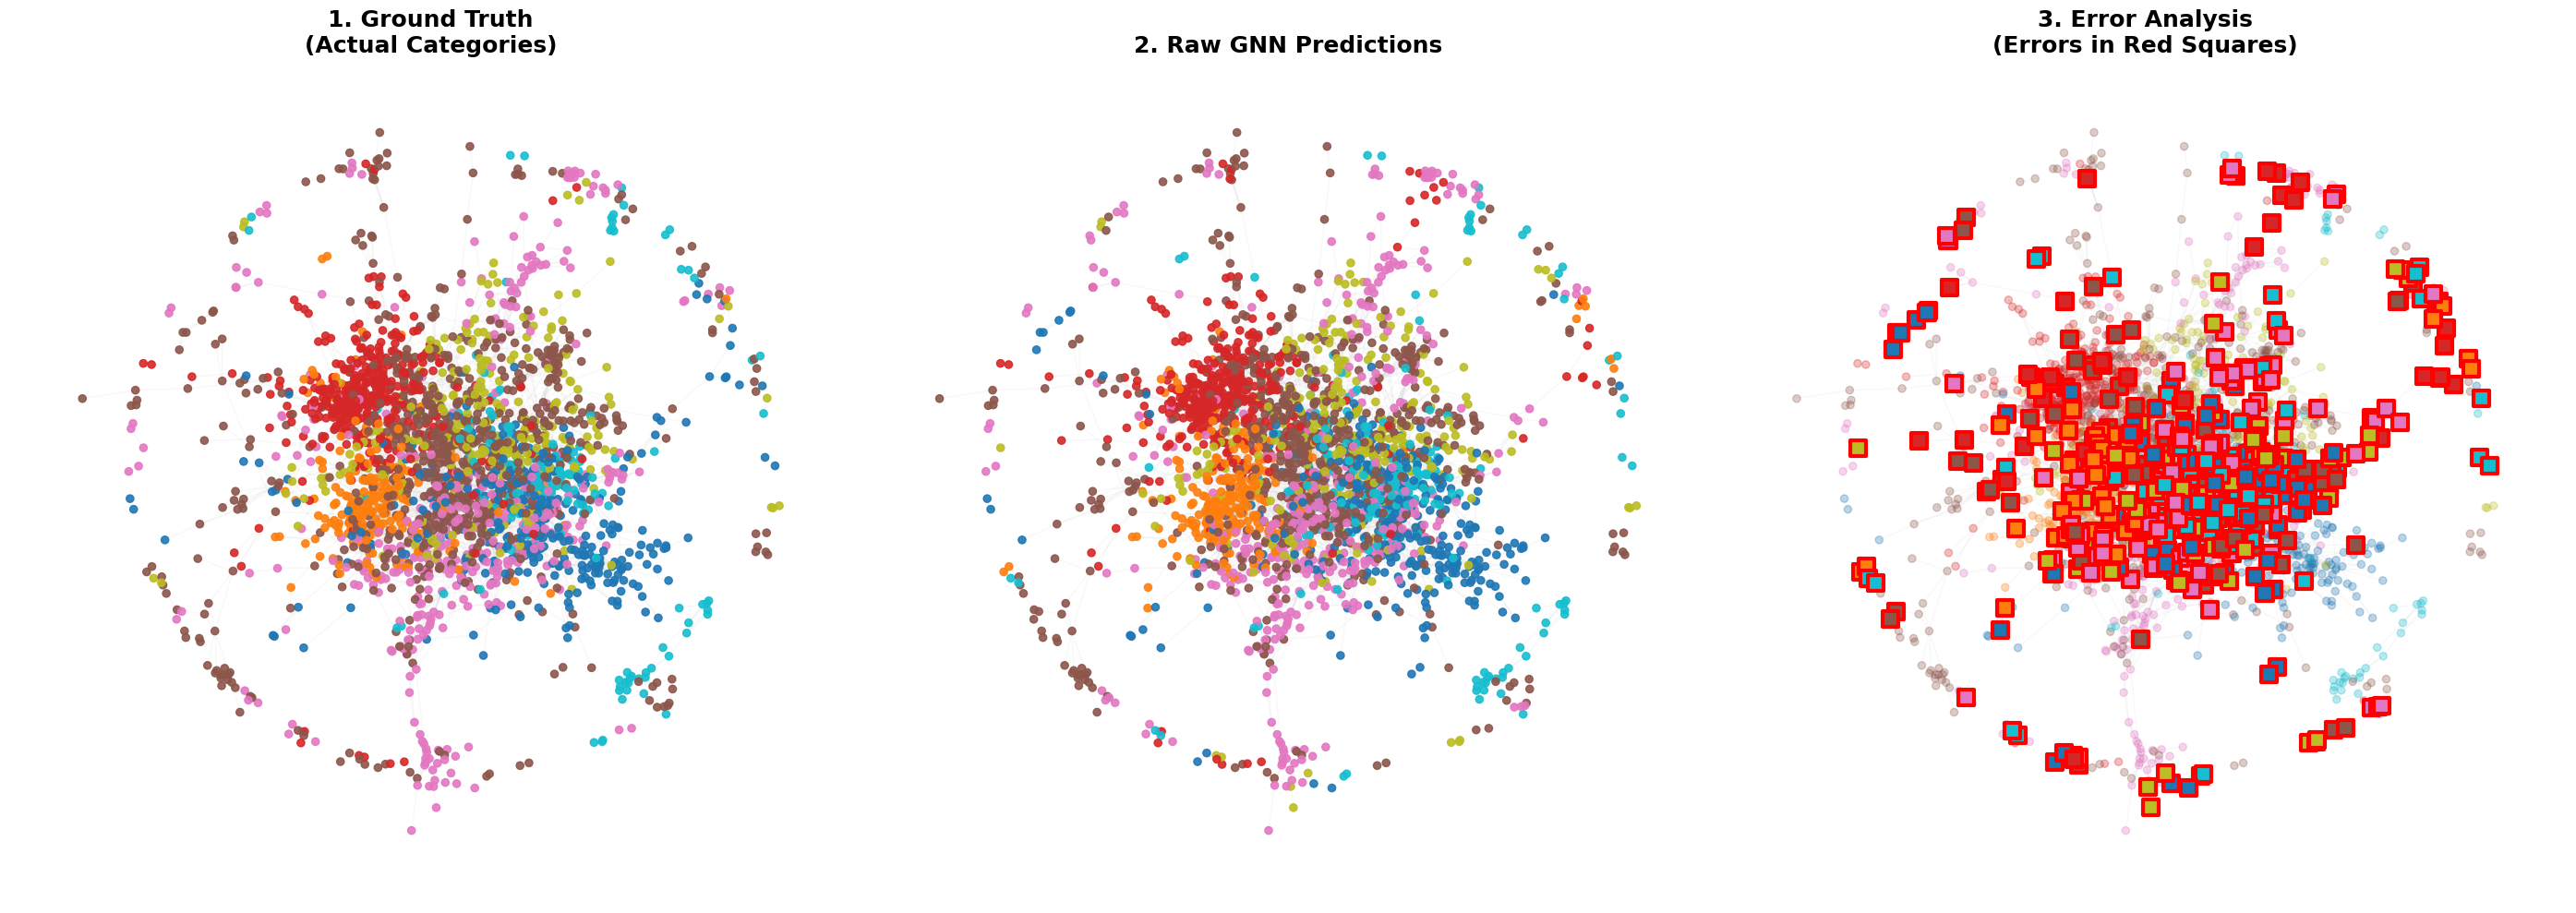

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx
import numpy as np

metric_names = ["accuracy", "precision", "recall", "f1"]
comparison_order = ["GCN", "GAT"]

fig = plt.figure(figsize=(24, 8))
grid = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.2, 1.2])
ax_metrics = fig.add_subplot(grid[0, 0])
ax_gcn = fig.add_subplot(grid[0, 1])
ax_gat = fig.add_subplot(grid[0, 2])

x = np.arange(len(metric_names))
bar_width = 0.35
for index, name in enumerate(comparison_order):
    scores = [model_results[name][metric] for metric in metric_names]
    offset = (index - 0.5) * bar_width
    ax_metrics.bar(x + offset, scores, width=bar_width, label=name, alpha=0.85)

ax_metrics.set_xticks(x)
ax_metrics.set_xticklabels([metric.title() for metric in metric_names])
ax_metrics.set_ylim(0, 1)
ax_metrics.set_ylabel("Score")
ax_metrics.set_title("GCN vs GAT Test Metrics", fontsize=16, fontweight="bold")
ax_metrics.legend()

G = to_networkx(data.cpu(), to_undirected=True)
print("Calculating graph layout... (this might take 10-20 seconds)")
pos = nx.spring_layout(G, seed=42)
truth = data.y.cpu().numpy()
cmap = plt.get_cmap("tab10")

for ax, name in zip((ax_gcn, ax_gat), comparison_order):
    pred = model_results[name]["pred"].numpy()
    wrong_nodes = np.where(pred != truth)[0]
    right_nodes = np.where(pred == truth)[0]

    nx.draw_networkx_edges(G, pos, edge_color="lightgray", alpha=0.15, ax=ax)
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=right_nodes.tolist(),
        node_color=pred[right_nodes],
        cmap=cmap,
        node_size=35,
        alpha=0.35,
        ax=ax,
    )
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=wrong_nodes.tolist(),
        node_color=pred[wrong_nodes],
        cmap=cmap,
        node_size=150,
        alpha=1.0,
        edgecolors="red",
        linewidths=2.5,
        node_shape="s",
        ax=ax,
    )
    ax.set_title(f"{name} Error Analysis\nErrors in Red Squares", fontsize=16, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
import matplotlib.pyplot as plt

comparison_order = ["GCN", "GAT"]
fig, axes = plt.subplots(1, len(comparison_order), figsize=(14, 6))

for ax, name in zip(axes, comparison_order):
    results = model_results[name]
    cm = confusion_matrix(results["y_true"], results["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(dataset.num_classes)))
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"{name} Confusion Matrix", fontsize=14, fontweight="bold")
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")

plt.tight_layout()
plt.show()

for name in comparison_order:
    results = model_results[name]
    print(f"{name} overall test accuracy: {results['accuracy'] * 100:.2f}%")
    print("--- Detailed breakdown per class ---")
    print(classification_report(results["y_true"], results["y_pred"], zero_division=0))
    print()

OVERALL TEST ACCURACY: 80.10%
(Got 801 correct out of 1000 test documents)

--- DETAILED BREAKDOWN PER CLASS ---
              precision    recall  f1-score   support

           0       0.66      0.71      0.68       130
           1       0.79      0.87      0.83        91
           2       0.90      0.90      0.90       144
           3       0.89      0.76      0.82       319
           4       0.79      0.81      0.80       149
           5       0.75      0.78      0.77       103
           6       0.65      0.86      0.74        64

    accuracy                           0.80      1000
   macro avg       0.78      0.81      0.79      1000
weighted avg       0.81      0.80      0.80      1000



## Conclusion

In this workshop, we:
1. Learned what graphs are and how to represent them.
2. Built our own graphs in PyTorch Geometric.
3. Implemented a Graph Convolutional Network (GCN) for Node Classification.